In [8]:
import numpy as np


dt = 0.004
    #     alpha = state.metrics['motor_alpha']
    #     rpm_proxy = jp.sqrt(action_scaled)  # we use sqrt of thrust as a proxy for rotor speed
    #     r_prev = state.metrics['filtered_rpm_proxy']
    #     filtered_rpm_proxy = r_prev + alpha * (rpm_proxy - r_prev)
    #     filtered_thrust = jp.square(filtered_rpm_proxy)  # convert back to thrust


def apply_motor_filter(action_scaled: np.ndarray,
                       prev_filtered_rpm_proxy: np.ndarray,
                       ):
   
    tau = 0.15/4 #T/4
    alpha = dt / tau  

    next_filtered_rpm_proxy = prev_filtered_rpm_proxy + alpha * (np.sqrt(action_scaled) - prev_filtered_rpm_proxy)
    filtered_thrust = np.square(next_filtered_rpm_proxy)
    return filtered_thrust, next_filtered_rpm_proxy


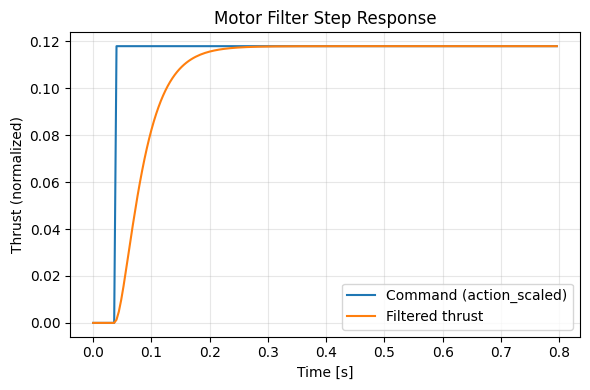

In [9]:

import matplotlib.pyplot as plt
import numpy as np

n_steps = 200
step_at = 10 
u = np.ones(n_steps)* 0.118
u[:step_at] = 0.0  # step 


filtered_thrust_hist = []
rpm_proxy_hist = []


filtered_rpm_prev = np.zeros(1)

for a in u:
    thrust_filt, filtered_rpm_prev = apply_motor_filter(np.array([a]), filtered_rpm_prev)
    filtered_thrust_hist.append(thrust_filt[0])
    rpm_proxy_hist.append(filtered_rpm_prev[0])

filtered_thrust_hist = np.array(filtered_thrust_hist)
rpm_proxy_hist = np.array(rpm_proxy_hist)


t = np.arange(n_steps) * dt

plt.figure(figsize=(6,4))
plt.plot(t, u, label='Command (action_scaled)')
plt.plot(t, filtered_thrust_hist, label='Filtered thrust')
plt.xlabel('Time [s]')
plt.ylabel('Thrust (normalized)')
plt.title('Motor Filter Step Response')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()